In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("dataset.csv")
df

,region,date,consumption_liters
0,North,2023-01-01,11673.07
1,North,2023-01-02,14736.03
2,North,2023-01-03,19370.75
3,North,2023-01-04,17774.55
4,North,2023-01-05,14972.58
...,...,...,...
895,Central,2023-06-25,13696.64
896,Central,2023-06-26,14407.92
897,Central,2023-06-27,15759.11
898,Central,2023-06-28,10404.03


In [6]:
df=df.dropna()


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   region              900 non-null    str    
 1   date                900 non-null    str    
 2   consumption_liters  900 non-null    float64
dtypes: float64(1), str(2)
memory usage: 21.2 KB


In [8]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
df

,region,date,consumption_liters
0,North,2023-01-01,11673.07
1,North,2023-01-02,14736.03
2,North,2023-01-03,19370.75
3,North,2023-01-04,17774.55
4,North,2023-01-05,14972.58
...,...,...,...
895,Central,2023-06-25,13696.64
896,Central,2023-06-26,14407.92
897,Central,2023-06-27,15759.11
898,Central,2023-06-28,10404.03


In [10]:
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

In [11]:
df.head()

,region,date,consumption_liters,day,month,year
0,North,2023-01-01,11673.07,1,1,2023
1,North,2023-01-02,14736.03,2,1,2023
2,North,2023-01-03,19370.75,3,1,2023
3,North,2023-01-04,17774.55,4,1,2023
4,North,2023-01-05,14972.58,5,1,2023


In [13]:
X = df[['day', 'month', 'year']]
y = df['consumption_liters']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [16]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
predictions = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 3649.354186848723
R2 Score: 0.013623180358915965


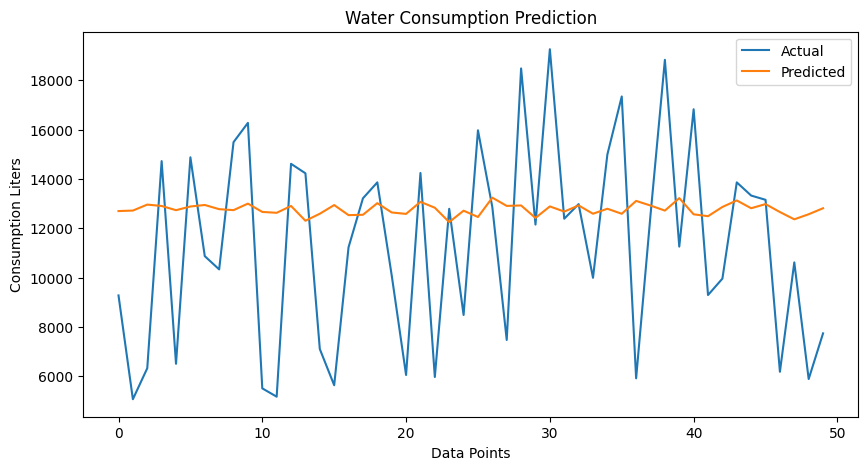

In [21]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label='Actual')
plt.plot(predictions[:50], label='Predicted')

plt.xlabel("Data Points")
plt.ylabel("Consumption Liters")

plt.title("Water Consumption Prediction")

plt.legend()

plt.show()